# Bien-être numérique : Impact du temps d'écran sur le sommeil et le stress

## Contexte
Ce notebook constitue la phase d'**analyse exploratoire et de nettoyage des données** du projet. L'objectif est de comprendre la structure du jeu de données, d'identifier les problèmes de qualité, et de préparer les données pour la modélisation.

**Problématique principale :** Comment quantifier l'impact du temps d'écran journalier sur la durée du sommeil et le niveau de stress ?

---
### Plan du notebook
1. Chargement des données et imports
2. Aperçu général du dataset
3. Statistiques descriptives
4. Détection et traitement des valeurs manquantes
5. Détection et traitement des doublons
6. Analyse et traitement des valeurs aberrantes (outliers)
7. Analyse des distributions
8. Analyse des corrélations
9. Analyse bivariée (temps d'écran → sommeil & stress)
10. Analyse par profil (genre, profession)
11. Synthèse et export du dataset nettoyé

## 1. Chargement des données et imports

On commence par importer toutes les bibliothèques nécessaires. Chaque bibliothèque a un rôle précis :
- **pandas** : manipulation et analyse des données tabulaires
- **numpy** : calculs numériques
- **matplotlib / seaborn** : visualisations statistiques
- **scipy** : tests statistiques

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14

print('Bibliothèques importées avec succès')

Bibliothèques importées avec succès


In [2]:
# Chargement du fichier CSV
FILE_PATH = 'sleep_mobile_stress_dataset_15000.csv'

df_raw = pd.read_csv(FILE_PATH)

# On garde une copie intacte des données brutes pour référence
df = df_raw.copy()

print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Dataset chargé : 15,000 lignes × 13 colonnes


## 2. Aperçu général du dataset

Avant toute analyse, on doit **comprendre la structure** du jeu de données : quelles colonnes existent, quels types de données, et à quoi ressemblent les premières observations.

In [36]:
# Premières lignes du dataset
df.head(10)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99
5,6,56,Male,Teacher,7.26,10,7.79,6.16,10.00,2,50,198,7.85
6,7,36,Female,Teacher,4.56,83,6.81,6.81,5.38,0,19,39,5.52
7,8,40,Male,Manager,3.36,89,6.50,8.75,3.48,2,66,127,4.50
8,9,28,Male,Student,2.30,109,7.57,8.05,3.46,3,103,99,2.52
9,10,28,Female,Manager,9.75,46,4.73,5.52,10.00,3,56,121,10.00


In [5]:
# Types de données et valeurs non nulles par colonne
# .info() est le premier réflexe : il révèle les types et les valeurs manquantes
print('=== INFO GÉNÉRALE ===')
df.info()

=== INFO GÉNÉRALE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-n

In [6]:
# Description des colonnes
colonnes_description = {
    'user_id'                          : 'Identifiant unique de l\'utilisateur',
    'age'                              : 'Âge en années',
    'gender'                           : 'Genre (Male / Female)',
    'occupation'                       : 'Profession',
    'daily_screen_time_hours'          : 'Temps d\'écran quotidien (heures)',
    'phone_usage_before_sleep_minutes' : 'Utilisation du téléphone avant de dormir (minutes)',
    'sleep_duration_hours'             : 'Durée du sommeil (heures)  ← variable cible 1',
    'sleep_quality_score'              : 'Score de qualité du sommeil (0-10)',
    'stress_level'                     : 'Niveau de stress (0-10)  ← variable cible 2',
    'caffeine_intake_cups'             : 'Consommation de caféine (tasses/jour)',
    'physical_activity_minutes'        : 'Activité physique quotidienne (minutes)',
    'notifications_received_per_day'   : 'Nombre de notifications reçues par jour',
    'mental_fatigue_score'             : 'Score de fatigue mentale (0-10)',
}

desc_df = pd.DataFrame.from_dict(colonnes_description, orient='index', columns=['Description'])
desc_df.index.name = 'Colonne'
desc_df

,Description
Colonne,
user_id,Identifiant unique de l'utilisateur
age,Âge en années
gender,Genre (Male / Female)
occupation,Profession
daily_screen_time_hours,Temps d'écran quotidien (heures)
phone_usage_before_sleep_minutes,Utilisation du téléphone avant de dormir (minu...
sleep_duration_hours,Durée du sommeil (heures) ← variable cible 1
sleep_quality_score,Score de qualité du sommeil (0-10)
stress_level,Niveau de stress (0-10) ← variable cible 2


## 3. Statistiques descriptives

Les statistiques descriptives donnent une vue d'ensemble quantitative : moyenne, médiane, écart-type, min, max. C'est essentiel pour repérer des anomalies avant de regarder les graphiques.

In [7]:
# Statistiques pour les variables numériques
# On transpose pour une lecture plus facile
stats_num = df.describe().T
stats_num['cv (%)'] = (stats_num['std'] / stats_num['mean'] * 100).round(1)  # Coefficient de variation
stats_num.round(3)

,count,mean,std,min,25%,50%,75%,max,cv (%)
user_id,15000.0,7500.500,4330.271,1.0,3750.75,7500.50,11250.25,15000.0,57.7
age,15000.0,38.488,12.008,18.0,28.00,38.00,49.00,59.0,31.2
daily_screen_time_hours,15000.0,5.502,2.600,1.0,3.26,5.49,7.76,10.0,47.3
phone_usage_before_sleep_minutes,15000.0,59.709,34.642,0.0,29.00,60.00,90.00,119.0,58.0
sleep_duration_hours,15000.0,6.510,1.453,4.0,5.26,6.49,7.79,9.0,22.3
sleep_quality_score,15000.0,6.246,1.714,1.0,5.00,6.25,7.50,10.0,27.4
stress_level,15000.0,6.980,2.749,1.0,4.75,7.38,10.00,10.0,39.4
caffeine_intake_cups,15000.0,1.999,1.415,0.0,1.00,2.00,3.00,4.0,70.8
physical_activity_minutes,15000.0,59.157,34.526,0.0,29.00,59.00,89.00,119.0,58.4
notifications_received_per_day,15000.0,160.890,80.857,20.0,92.00,162.00,231.00,299.0,50.3


In [8]:
# Statistiques pour les variables catégorielles
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Colonnes catégorielles : {cat_cols}\n')

for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print(f'  → {df[col].nunique()} valeurs uniques\n')

Colonnes catégorielles : ['gender', 'occupation']

--- gender ---
gender
Male      7234
Female    7181
Other      585
Name: count, dtype: int64
  → 3 valeurs uniques

--- occupation ---
occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64
  → 8 valeurs uniques



## 4. Détection et traitement des valeurs manquantes

Les **valeurs manquantes** (NaN) peuvent biaiser les analyses et les modèles. On les détecte d'abord, puis on décide d'une stratégie : suppression, imputation par la moyenne/médiane/mode, ou interpolation.

In [38]:
# Calcul du nombre et du pourcentage de valeurs manquantes par colonne
missing = pd.DataFrame({
    'Valeurs manquantes' : df.isnull().sum(),
    'Pourcentage (%)'    : (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Valeurs manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)

if missing.empty:
    print('Aucune valeur manquante détectée dans le dataset')
else:
    print(f' {len(missing)} colonnes avec des valeurs manquantes :')
    print(missing)

Aucune valeur manquante détectée dans le dataset


## 5. Détection et suppression des doublons

Des **lignes dupliquées** peuvent gonfler artificiellement les statistiques et biaiser les modèles. On vérifie à la fois les doublons exacts (toutes colonnes) et les doublons sur `user_id` (qui doit être unique).

In [40]:
# Doublons exacts (toutes colonnes identiques)
n_doublons = df.duplicated().sum()
print(f'Doublons exacts : {n_doublons}')

# Doublons sur user_id uniquement
n_doublons_id = df.duplicated(subset='user_id').sum()
print(f'user_id dupliqués : {n_doublons_id}')

if n_doublons > 0:
    print('\nExemples de doublons :')
    print(df[df.duplicated(keep=False)].head(6))
    
    # Suppression des doublons exacts
    df = df.drop_duplicates()
    print(f'\nDoublons supprimés. Dataset : {df.shape[0]:,} lignes restantes.')
else:
    print('\nAucun doublon détecté.')

Doublons exacts : 0
user_id dupliqués : 0

Aucun doublon détecté.


In [41]:
# Vérification de la cohérence de user_id : doit aller de 1 à N sans trou
ids = df['user_id'].sort_values().values
expected = np.arange(1, len(ids) + 1)
gaps = set(expected) - set(ids)

print(f'user_id min : {df["user_id"].min()}, max : {df["user_id"].max()}')
print(f'Nombre d\'IDs uniques : {df["user_id"].nunique()}')
if gaps:
    print(f'IDs manquants dans la séquence : {sorted(gaps)[:10]}...')
else:
    print('Séquence d\'IDs continue et cohérente.')

user_id min : 1, max : 15000
Nombre d'IDs uniques : 15000
Séquence d'IDs continue et cohérente.


## 6. Analyse et traitement des valeurs aberrantes (outliers)

Les **outliers** sont des valeurs extrêmes qui peuvent indiquer :
- Des **erreurs de saisie** (ex : 25 heures de sommeil)
- Des **cas réels rares** qu'il faut conserver

On utilise deux méthodes complémentaires :
- **Méthode IQR** : valeurs en dehors de [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
- **Méthode des bornes métier** : bornes logiques selon le domaine

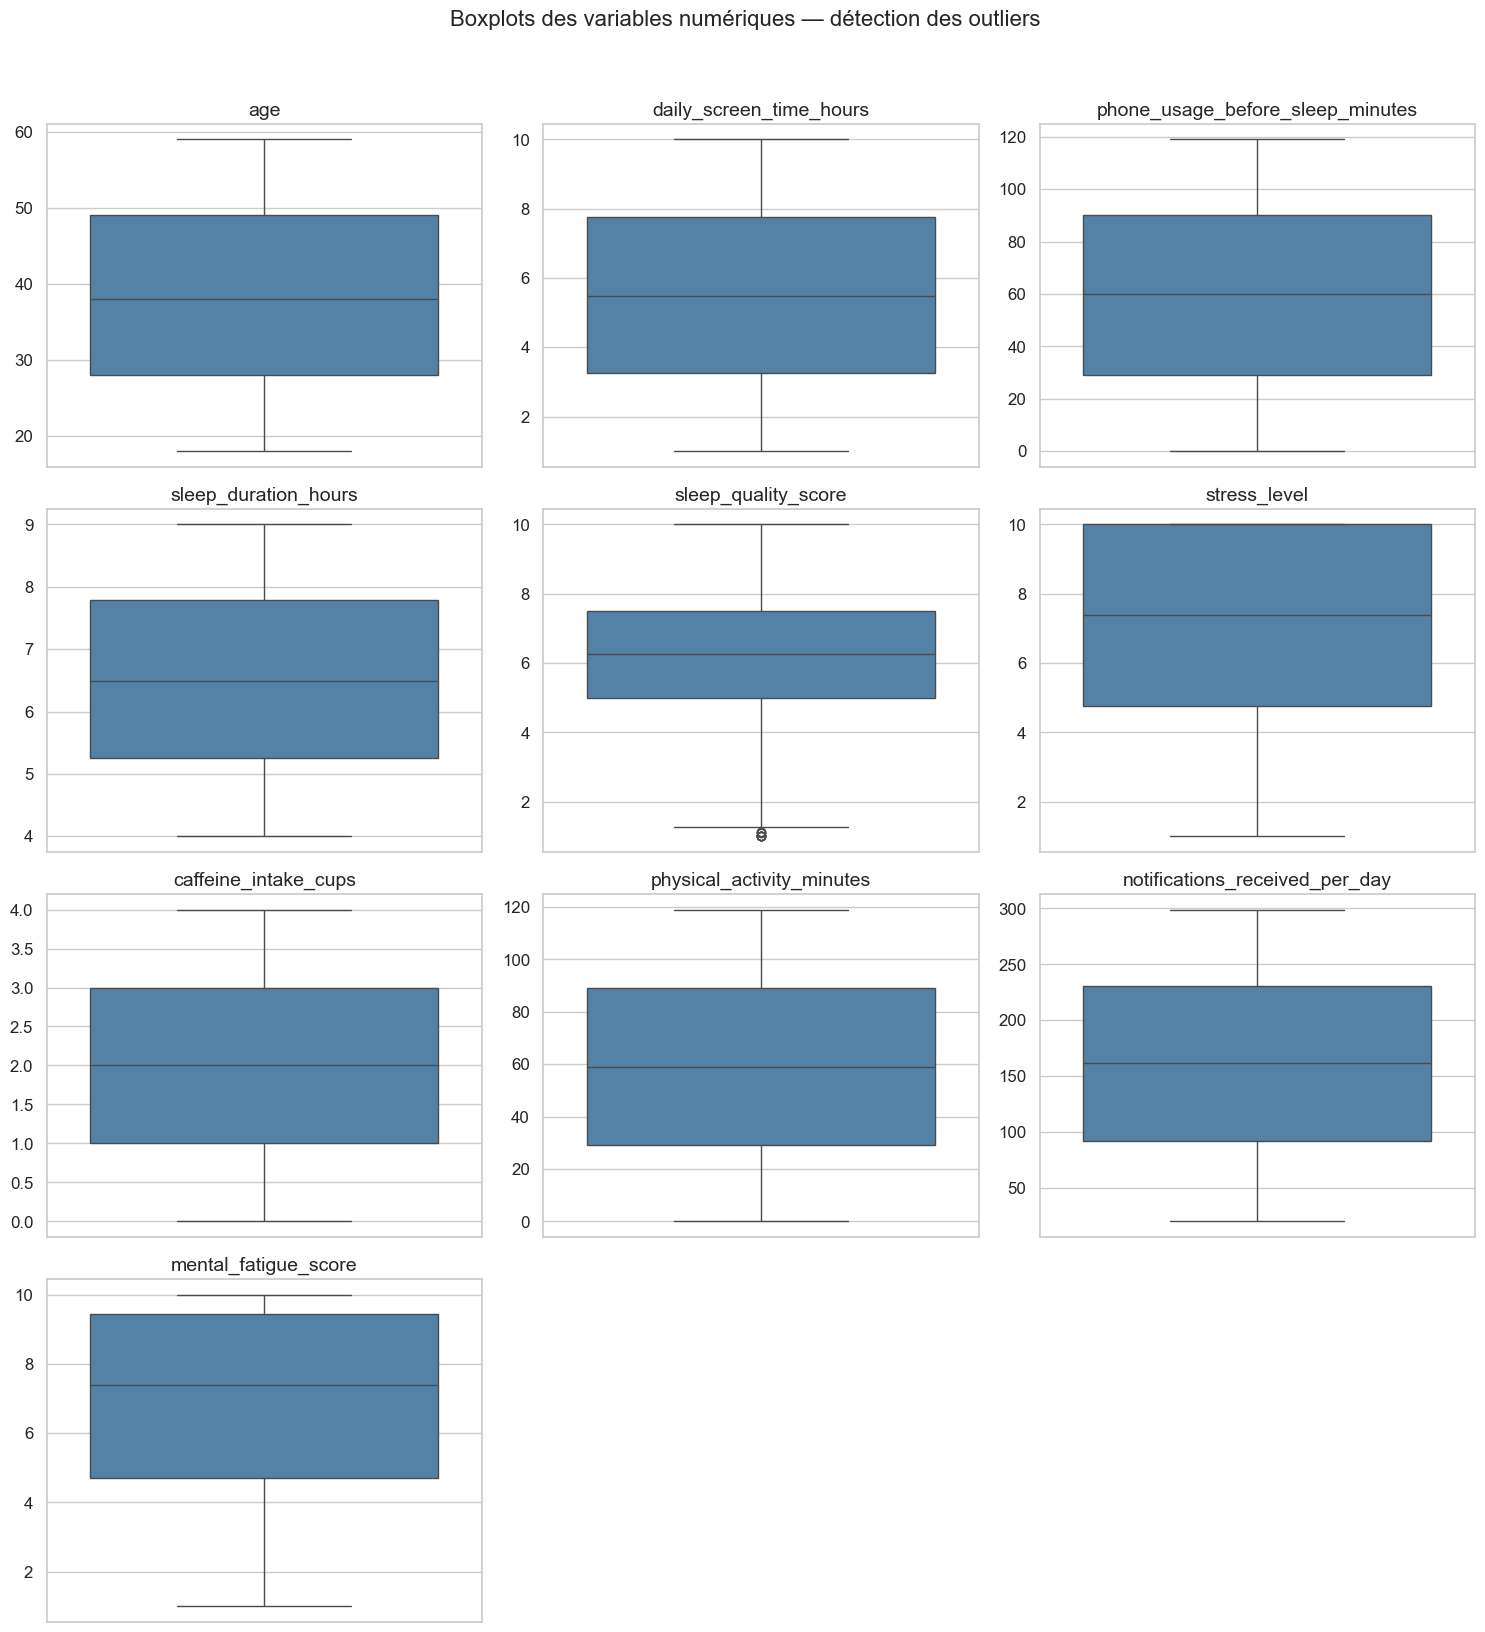

In [13]:
# Boxplots pour toutes les variables numériques (hors user_id)
num_cols = df.select_dtypes(include=np.number).columns.drop('user_id').tolist()

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots des variables numériques — détection des outliers', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
# Méthode IQR : comptage des outliers par colonne
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper

outlier_report = []
for col in num_cols:
    n_out, low, up = count_outliers_iqr(df[col])
    outlier_report.append({
        'Colonne'             : col,
        'Nb outliers (IQR)'   : n_out,
        '% du dataset'        : round(n_out / len(df) * 100, 2),
        'Borne inférieure'    : round(low, 2),
        'Borne supérieure'    : round(up, 2),
        'Min observé'         : df[col].min(),
        'Max observé'         : df[col].max(),
    })

pd.DataFrame(outlier_report).set_index('Colonne')

,Nb outliers (IQR),% du dataset,Borne inférieure,Borne supérieure,Min observé,Max observé
Colonne,,,,,,
age,0,0.00,-3.50,80.50,18.0,59.0
daily_screen_time_hours,0,0.00,-3.49,14.51,1.0,10.0
phone_usage_before_sleep_minutes,0,0.00,-62.50,181.50,0.0,119.0
sleep_duration_hours,0,0.00,1.46,11.58,4.0,9.0
sleep_quality_score,9,0.06,1.25,11.25,1.0,10.0
stress_level,0,0.00,-3.12,17.88,1.0,10.0
caffeine_intake_cups,0,0.00,-2.00,6.00,0.0,4.0
physical_activity_minutes,0,0.00,-61.00,179.00,0.0,119.0
notifications_received_per_day,0,0.00,-116.50,439.50,20.0,299.0


In [42]:
# Vérification des bornes métier (cohérence logique des valeurs)
bornes_metier = {
    'age'                              : (10, 100),
    'daily_screen_time_hours'          : (0, 24),
    'phone_usage_before_sleep_minutes' : (0, 180),
    'sleep_duration_hours'             : (0, 24),
    'sleep_quality_score'              : (0, 10),
    'stress_level'                     : (0, 10),
    'caffeine_intake_cups'             : (0, 20),
    'physical_activity_minutes'        : (0, 600),
    'notifications_received_per_day'   : (0, 1000),
    'mental_fatigue_score'             : (0, 10),
}

print('Vérification des bornes métier :')
anomalies_trouvees = False
for col, (low, up) in bornes_metier.items():
    mask = (df[col] < low) | (df[col] > up)
    n = mask.sum()
    if n > 0:
        anomalies_trouvees = True
        print(f'     {col} : {n} valeurs hors [{low}, {up}]')
        print(f'         Valeurs : {df.loc[mask, col].values[:10]}')

if not anomalies_trouvees:
    print('  Toutes les valeurs sont dans des bornes logiques.')

Vérification des bornes métier :
  Toutes les valeurs sont dans des bornes logiques.


In [16]:
# Stratégie de traitement des outliers :
# On utilise le winsorizing (écrêtage) sur les variables continues pour limiter
# l'influence des valeurs extrêmes sans supprimer de lignes.
# On conserve les lignes mais on bride les valeurs aux percentiles 1% et 99%.

df_clean = df.copy()

vars_to_winsorize = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'physical_activity_minutes',
    'notifications_received_per_day',
]

for col in vars_to_winsorize:
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    before_range = f'[{df_clean[col].min():.2f}, {df_clean[col].max():.2f}]'
    df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)
    after_range  = f'[{df_clean[col].min():.2f}, {df_clean[col].max():.2f}]'
    print(f'{col:<45} avant: {before_range:<20} après: {after_range}')

daily_screen_time_hours                       avant: [1.00, 10.00]        après: [1.09, 9.92]
phone_usage_before_sleep_minutes              avant: [0.00, 119.00]       après: [1.00, 118.00]
sleep_duration_hours                          avant: [4.00, 9.00]         après: [4.05, 8.95]
physical_activity_minutes                     avant: [0.00, 119.00]       après: [1.00, 118.00]
notifications_received_per_day                avant: [20.00, 299.00]      après: [22.00, 297.00]


## 7. Analyse des distributions

On visualise la **forme de la distribution** de chaque variable numérique. Cela permet de :
- Identifier les variables asymétriques (skewed)
- Vérifier si les variables cibles (sommeil, stress) suivent une loi normale
- Orienter les choix de modélisation

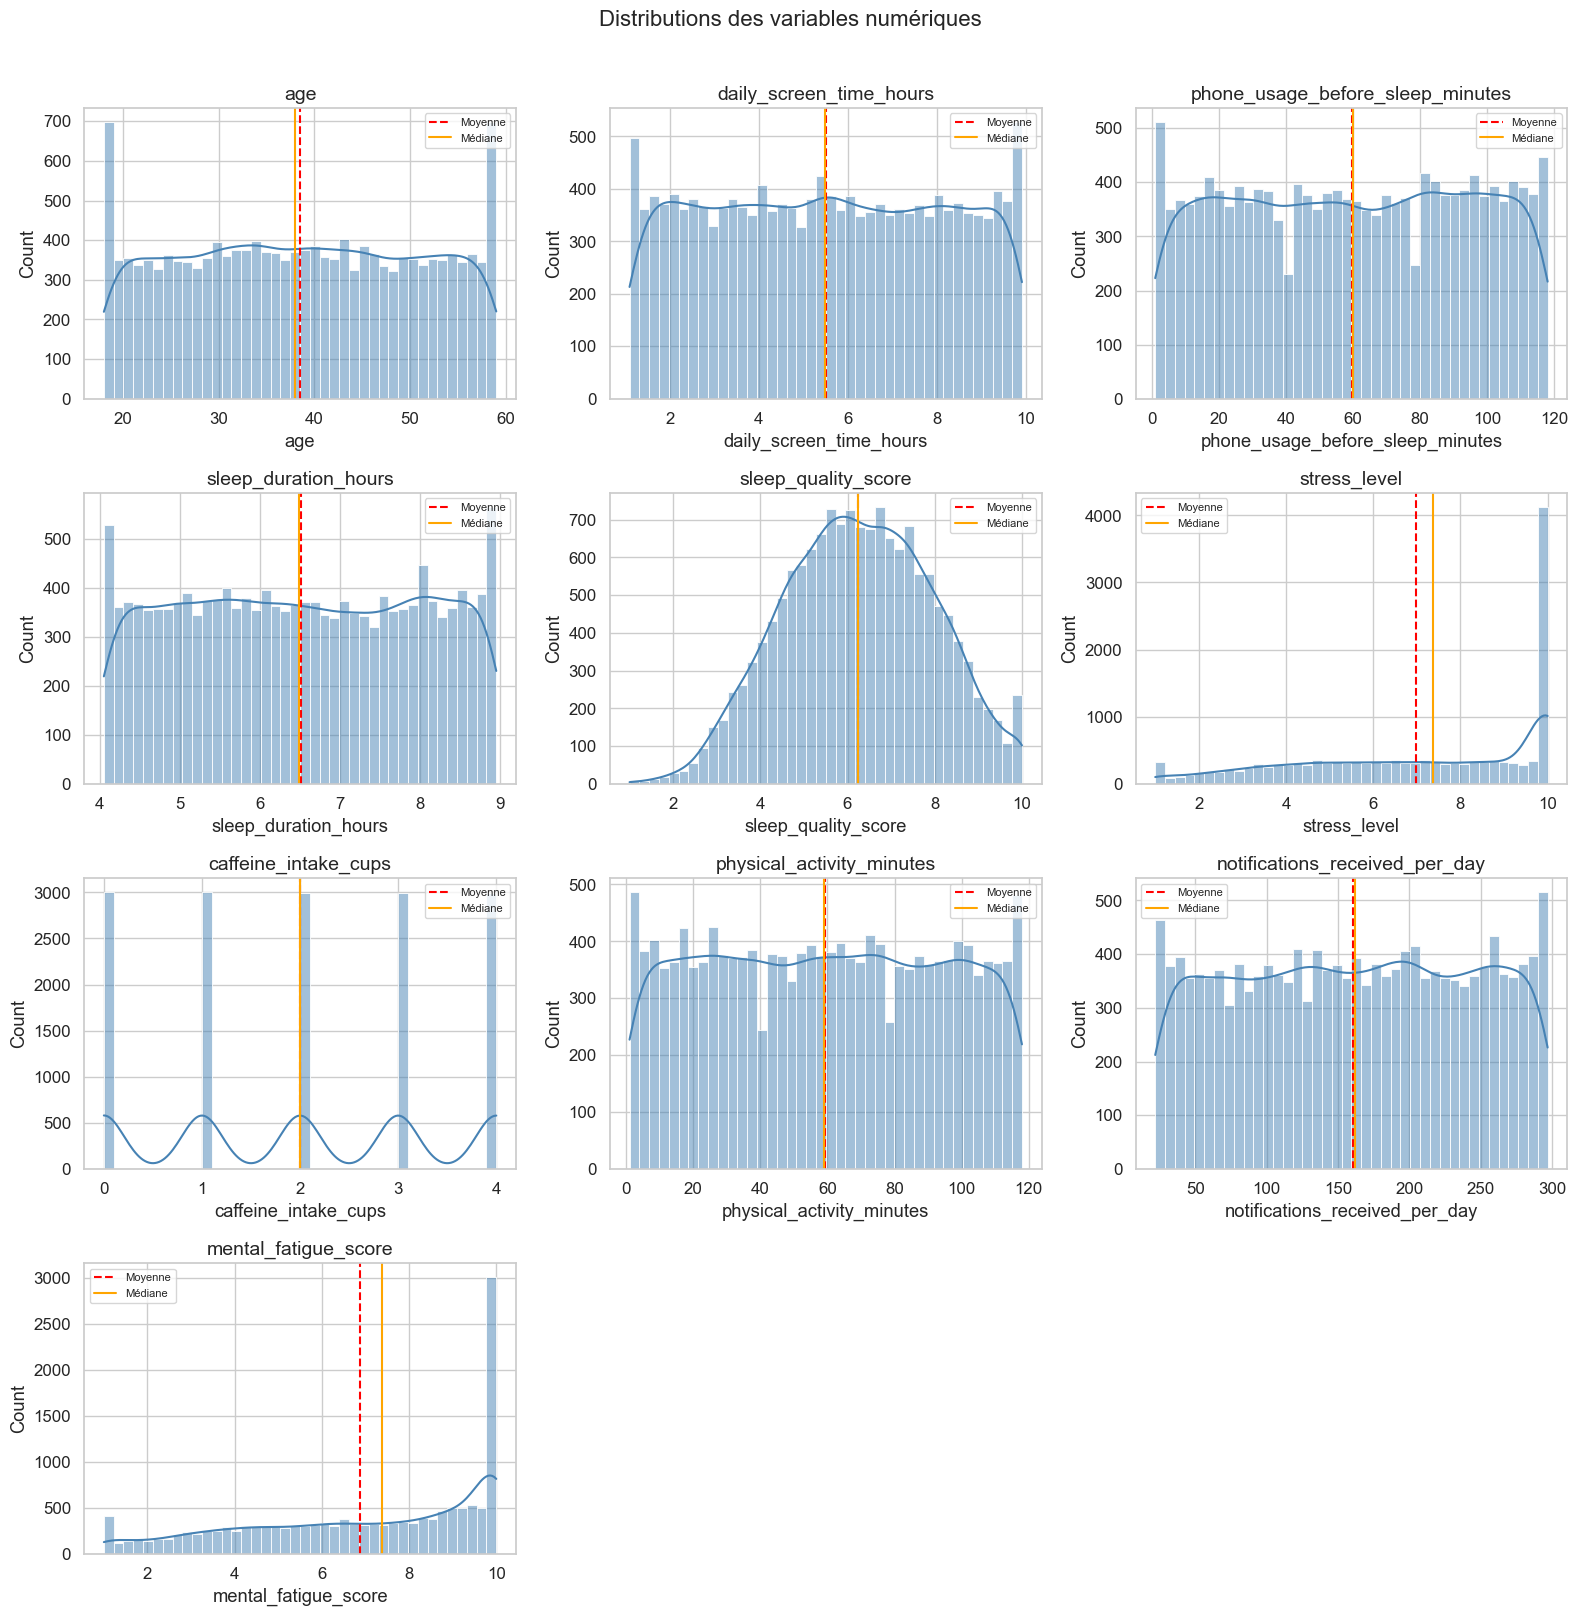

In [17]:
# Histogrammes + courbe KDE pour chaque variable numérique
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='steelblue', bins=40)
    # Ligne verticale : moyenne (rouge) et médiane (orange)
    axes[i].axvline(df_clean[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Moyenne')
    axes[i].axvline(df_clean[col].median(), color='orange', linestyle='-',  linewidth=1.5, label='Médiane')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des variables numériques', y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
# Test de normalité de Shapiro-Wilk pour les variables cibles
# (sur un échantillon de 5000 observations car Shapiro est limité)
variables_cibles = ['sleep_duration_hours', 'stress_level', 'sleep_quality_score', 'mental_fatigue_score']

sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=42)

print('Test de normalité de Shapiro-Wilk (H0 : la variable suit une loi normale)')
print(f'{"Variable":<40} {"Statistique W":>15} {"p-value":>12} {"Normale ?"}' )
print('-' * 80)
for col in variables_cibles:
    w_stat, p_val = stats.shapiro(sample[col])
    normale = '✅ Oui' if p_val > 0.05 else '❌ Non (p < 0.05)'
    print(f'{col:<40} {w_stat:>15.4f} {p_val:>12.6f} {normale}')

Test de normalité de Shapiro-Wilk (H0 : la variable suit une loi normale)
Variable                                   Statistique W      p-value Normale ?
--------------------------------------------------------------------------------
sleep_duration_hours                              0.9519     0.000000 ❌ Non (p < 0.05)
stress_level                                      0.8990     0.000000 ❌ Non (p < 0.05)
sleep_quality_score                               0.9949     0.000000 ❌ Non (p < 0.05)
mental_fatigue_score                              0.9098     0.000000 ❌ Non (p < 0.05)


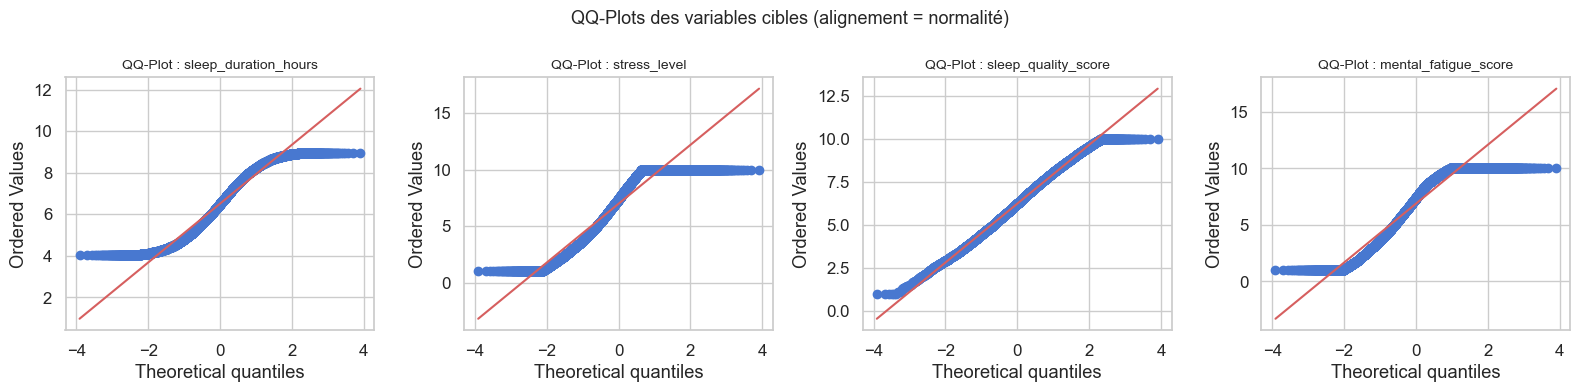

In [19]:
# QQ-Plots pour visualiser la normalité des variables cibles
fig, axes = plt.subplots(1, len(variables_cibles), figsize=(16, 4))

for i, col in enumerate(variables_cibles):
    stats.probplot(df_clean[col], dist='norm', plot=axes[i])
    axes[i].set_title(f'QQ-Plot : {col}', fontsize=10)

plt.suptitle('QQ-Plots des variables cibles (alignement = normalité)', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
# Skewness (asymétrie) et Kurtosis (aplatissement) de chaque variable
shape_stats = pd.DataFrame({
    'Skewness'  : df_clean[num_cols].skew().round(3),
    'Kurtosis'  : df_clean[num_cols].kurt().round(3),
})
shape_stats['Asymétrie']   = shape_stats['Skewness'].apply(
    lambda x: 'Forte droite' if x > 1 else ('Forte gauche' if x < -1 else 'Symétrique')
)
shape_stats

,Skewness,Kurtosis,Asymétrie
age,0.008,-1.171,Symétrique
daily_screen_time_hours,0.008,-1.200,Symétrique
phone_usage_before_sleep_minutes,-0.017,-1.220,Symétrique
sleep_duration_hours,0.003,-1.217,Symétrique
sleep_quality_score,-0.050,-0.520,Symétrique
stress_level,-0.466,-1.023,Symétrique
caffeine_intake_cups,0.001,-1.301,Symétrique
physical_activity_minutes,0.010,-1.199,Symétrique
notifications_received_per_day,-0.020,-1.193,Symétrique
mental_fatigue_score,-0.511,-0.946,Symétrique


## 8. Analyse des corrélations

La **matrice de corrélation** mesure la force et le sens des relations linéaires entre variables numériques. Un coefficient proche de ±1 indique une relation forte. On s'intéresse particulièrement aux corrélations avec `sleep_duration_hours` et `stress_level`.

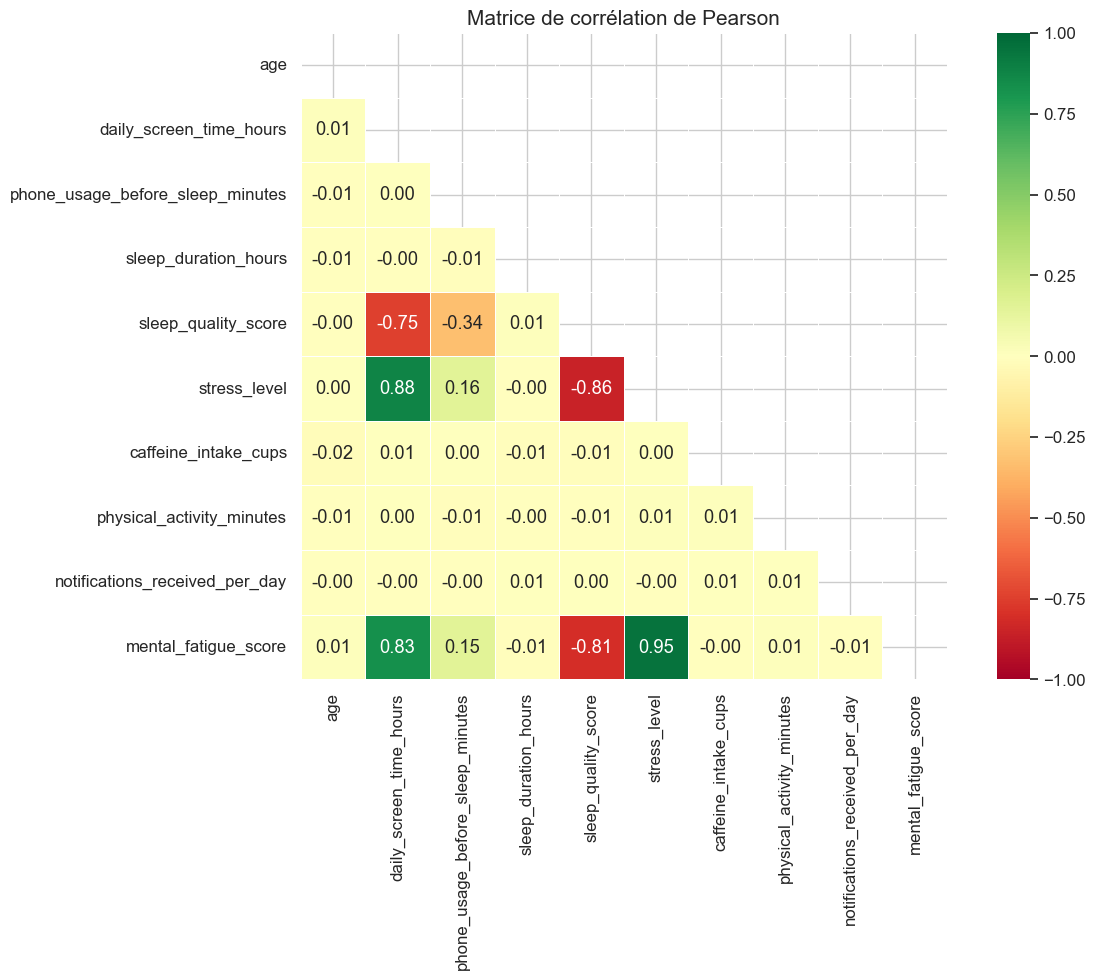

In [21]:
# Matrice de corrélation de Pearson
corr_matrix = df_clean[num_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Masque pour afficher seulement le triangle inf.

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matrice de corrélation de Pearson', fontsize=15)
plt.tight_layout()
plt.show()

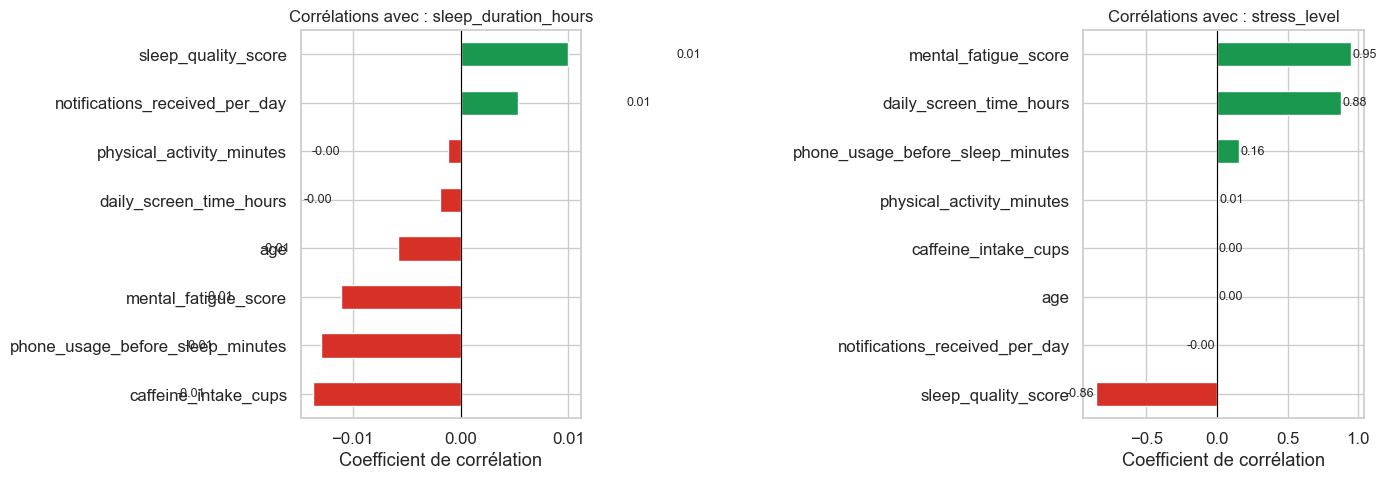

In [22]:
# Zoom sur les corrélations avec les variables cibles
targets = ['sleep_duration_hours', 'stress_level']
corr_targets = corr_matrix[targets].drop(index=targets).sort_values('sleep_duration_hours')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, targets):
    data = corr_targets[target].sort_values()
    colors = ['#d73027' if v < 0 else '#1a9850' for v in data.values]
    data.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Corrélations avec : {target}', fontsize=12)
    ax.set_xlabel('Coefficient de corrélation')
    for i, v in enumerate(data.values):
        ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.2f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
# Corrélation de Spearman (plus robuste aux distributions non normales)
corr_spearman = df_clean[num_cols].corr(method='spearman')[targets].drop(index=targets)

print('Corrélation de Spearman avec les variables cibles :')
corr_spearman.sort_values('stress_level', ascending=False)

Corrélation de Spearman avec les variables cibles :


,sleep_duration_hours,stress_level
mental_fatigue_score,-0.010440,0.930688
daily_screen_time_hours,-0.001866,0.893800
phone_usage_before_sleep_minutes,-0.012989,0.153515
physical_activity_minutes,-0.001101,0.008196
caffeine_intake_cups,-0.013896,0.004239
age,-0.005894,0.001525
notifications_received_per_day,0.005218,-0.002977
sleep_quality_score,0.009842,-0.882255


## 9. Analyse bivariée : temps d'écran → sommeil & stress

On explore maintenant la **relation directe** entre le temps d'écran (variable explicative principale) et nos deux variables cibles. Cette étape est au cœur de la problématique du projet.

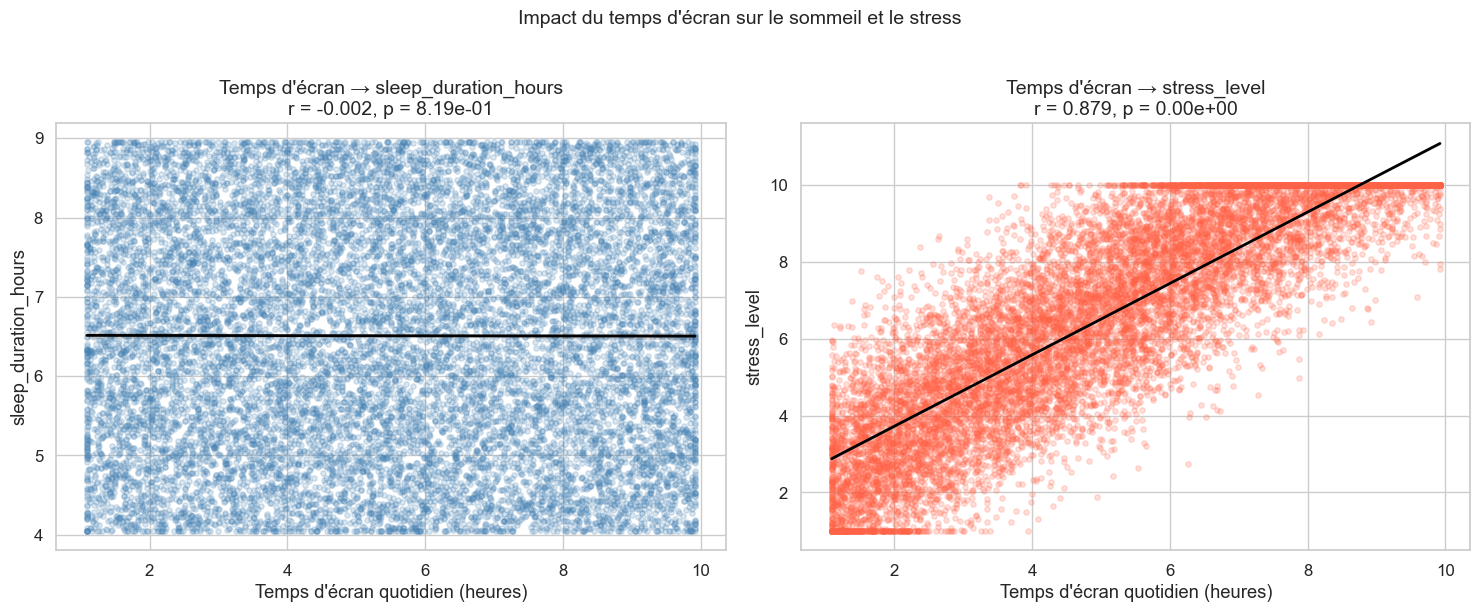

In [24]:
# Scatter plots avec droite de régression
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, target, color in zip(axes, targets, ['steelblue', 'tomato']):
    sns.regplot(
        data=df_clean,
        x='daily_screen_time_hours',
        y=target,
        ax=ax,
        scatter_kws={'alpha': 0.2, 's': 15, 'color': color},
        line_kws={'color': 'black', 'linewidth': 2},
        ci=95
    )
    r, p = stats.pearsonr(df_clean['daily_screen_time_hours'], df_clean[target])
    ax.set_title(f'Temps d\'écran → {target}\nr = {r:.3f}, p = {p:.2e}')
    ax.set_xlabel('Temps d\'écran quotidien (heures)')
    ax.set_ylabel(target)

plt.suptitle('Impact du temps d\'écran sur le sommeil et le stress', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Segmentation par tranches de temps d'écran pour une analyse plus fine
df_clean['screen_time_bin'] = pd.cut(
    df_clean['daily_screen_time_hours'],
    bins=[0, 2, 4, 6, 8, 25],
    labels=['< 2h', '2-4h', '4-6h', '6-8h', '> 8h']
)

# Statistiques par tranche
group_stats = df_clean.groupby('screen_time_bin', observed=True)[targets + ['mental_fatigue_score']].agg(['mean', 'median', 'std']).round(3)
print('Statistiques par tranche de temps d\'écran :')
group_stats

Statistiques par tranche de temps d'écran :


sleep_duration_hours               stress_level          \
                                mean median    std         mean  median   
screen_time_bin                                                           
< 2h                           6.511  6.495  1.434        2.900   2.785   
2-4h                           6.498  6.460  1.444        4.527   4.530   
4-6h                           6.517  6.480  1.465        6.796   6.805   
6-8h                           6.525  6.545  1.450        8.830   9.150   
> 8h                           6.499  6.480  1.458        9.834  10.000   

                       mental_fatigue_score                
                   std                 mean median    std  
screen_time_bin                                            
< 2h             1.394                2.996   2.82  1.584  
2-4h             1.649                4.535   4.47  1.886  
4-6h             1.618                6.780   6.81  1.825  
6-8h             1.255                8.659   9.02  1.377  
> 8h             0.469                9.482   9.89  0.743

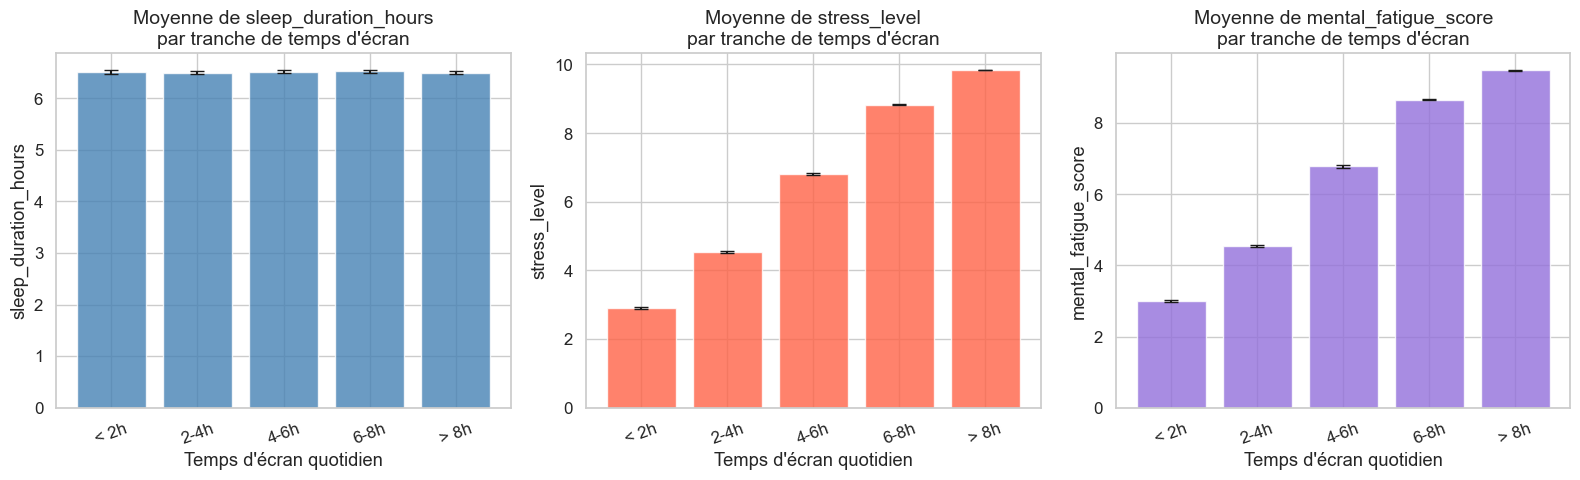

In [26]:
# Visualisation : évolution des moyennes par tranche de temps d'écran
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['sleep_duration_hours', 'stress_level', 'mental_fatigue_score']
colors  = ['steelblue', 'tomato', 'mediumpurple']

for ax, metric, color in zip(axes, metrics, colors):
    means = df_clean.groupby('screen_time_bin', observed=True)[metric].mean()
    sems  = df_clean.groupby('screen_time_bin', observed=True)[metric].sem()
    ax.bar(means.index, means.values, color=color, alpha=0.8, yerr=sems, capsize=5)
    ax.set_title(f'Moyenne de {metric}\npar tranche de temps d\'écran')
    ax.set_xlabel('Temps d\'écran quotidien')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

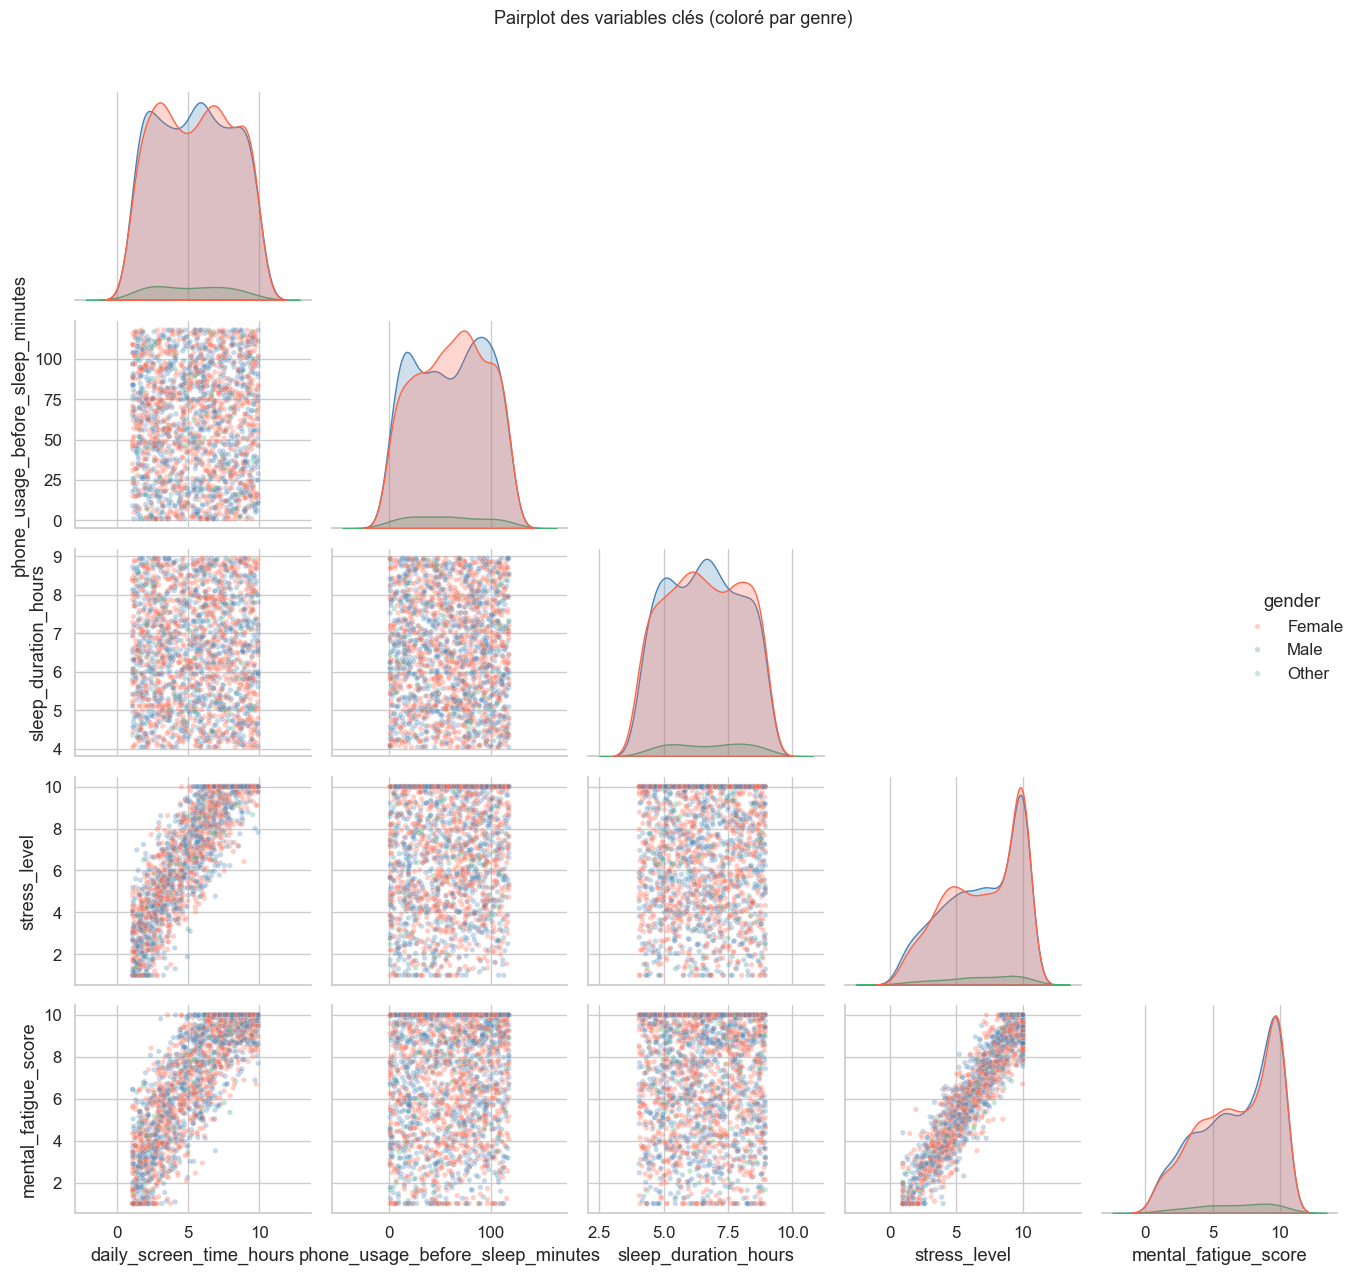

In [27]:
# Pairplot pour les variables les plus importantes
key_vars = ['daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
            'sleep_duration_hours', 'stress_level', 'mental_fatigue_score']

sample_plot = df_clean.sample(n=min(2000, len(df_clean)), random_state=42)

g = sns.pairplot(
    sample_plot[key_vars + ['gender']],
    hue='gender',
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15},
    palette={'Male': 'steelblue', 'Female': 'tomato', 'Other': 'mediumseagreen'},
    corner=True
)
g.figure.suptitle('Pairplot des variables clés (coloré par genre)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 10. Analyse par profil : genre et profession

Les habitudes numériques et leurs impacts peuvent varier selon les **caractéristiques socio-démographiques**. On analyse ici les différences par genre et par profession.

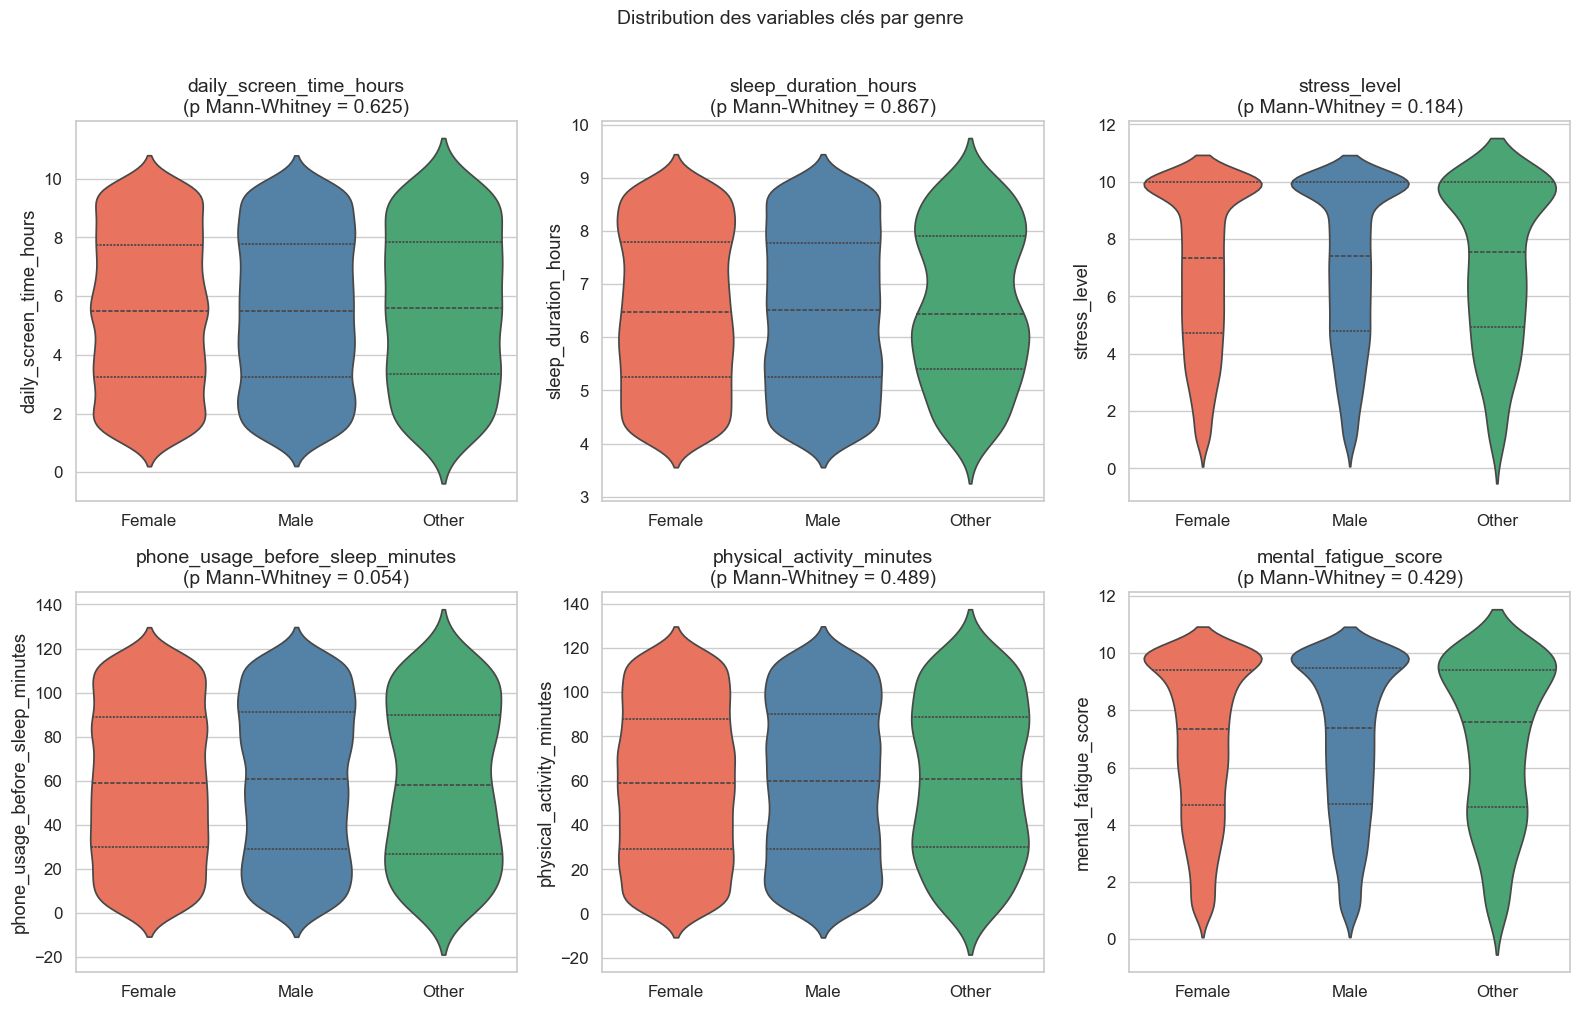

In [28]:
# Comparaison par genre
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
vars_to_plot = [
    'daily_screen_time_hours', 'sleep_duration_hours', 'stress_level',
    'phone_usage_before_sleep_minutes', 'physical_activity_minutes', 'mental_fatigue_score'
]

for ax, col in zip(axes.flatten(), vars_to_plot):
    sns.violinplot(
        data=df_clean, x='gender', y=col, ax=ax,
        palette={'Male': 'steelblue', 'Female': 'tomato', 'Other': 'mediumseagreen'},
        inner='quartile'
    )
    # Test de Mann-Whitney pour la différence entre les deux groupes
    male   = df_clean.loc[df_clean['gender'] == 'Male',   col]
    female = df_clean.loc[df_clean['gender'] == 'Female', col]
    _, p_val = stats.mannwhitneyu(male, female, alternative='two-sided')
    ax.set_title(f'{col}\n(p Mann-Whitney = {p_val:.3f})')
    ax.set_xlabel('')

plt.suptitle('Distribution des variables clés par genre', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# Analyse par profession
profession_stats = df_clean.groupby('occupation')[[
    'daily_screen_time_hours', 'sleep_duration_hours',
    'stress_level', 'mental_fatigue_score'
]].mean().round(2).sort_values('stress_level', ascending=False)

print('Moyennes par profession (triées par niveau de stress décroissant) :')
profession_stats

Moyennes par profession (triées par niveau de stress décroissant) :


,daily_screen_time_hours,sleep_duration_hours,stress_level,mental_fatigue_score
occupation,,,,
Student,5.63,6.53,7.18,7.04
Manager,5.54,6.52,7.06,6.97
Software Engineer,5.55,6.51,7.02,6.92
Doctor,5.49,6.45,6.97,6.87
Researcher,5.46,6.50,6.92,6.80
Freelancer,5.41,6.49,6.90,6.81
Teacher,5.47,6.54,6.90,6.81
Designer,5.45,6.54,6.87,6.75


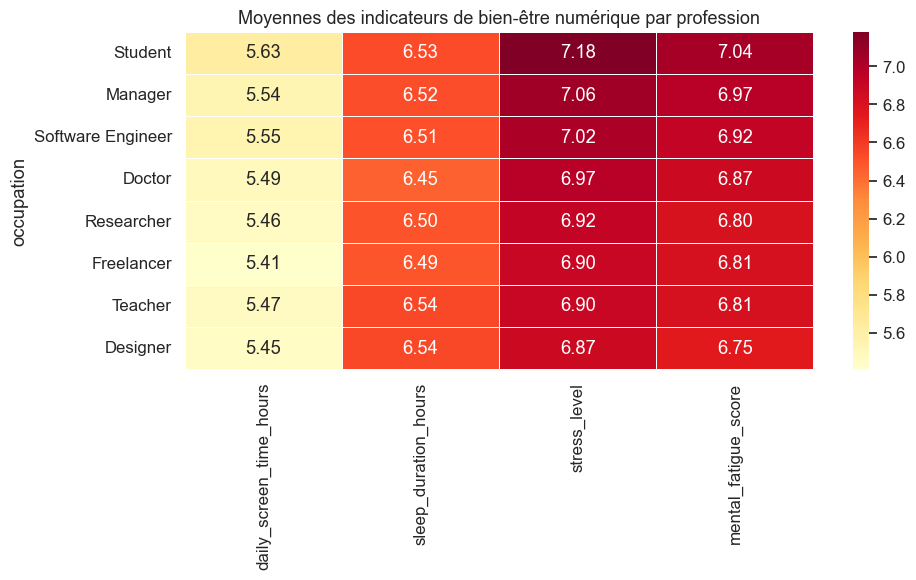

In [30]:
# Heatmap des moyennes par profession
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    profession_stats,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Moyennes des indicateurs de bien-être numérique par profession', fontsize=13)
plt.tight_layout()
plt.show()

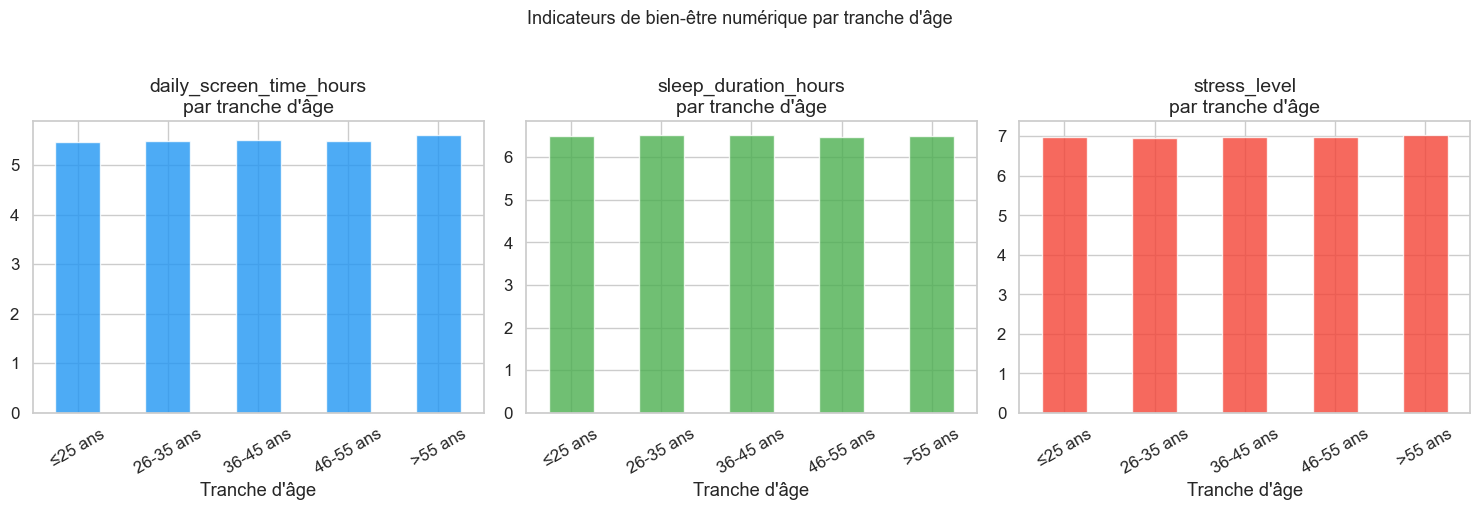

In [31]:
# Analyse par tranche d'âge
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['≤25 ans', '26-35 ans', '36-45 ans', '46-55 ans', '>55 ans']
)

age_stats = df_clean.groupby('age_group', observed=True)[[
    'daily_screen_time_hours', 'sleep_duration_hours', 'stress_level'
]].mean().round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2196F3', '#4CAF50', '#F44336']

for ax, col, color in zip(axes, age_stats.columns, colors):
    age_stats[col].plot(kind='bar', ax=ax, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col}\npar tranche d\'âge')
    ax.set_xlabel('Tranche d\'âge')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Indicateurs de bien-être numérique par tranche d\'âge', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Synthèse et export du dataset nettoyé

On récapitule toutes les transformations effectuées, puis on exporte le dataset propre prêt pour la modélisation.

In [44]:
# Récapitulatif du nettoyage
print('=' * 60)
print('RÉCAPITULATIF DU NETTOYAGE ET DE L\'ANALYSE')
print('=' * 60)
print(f'\n Dataset original     : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
print(f' Dataset nettoyé      : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes')
print(f'\n Valeurs manquantes   : {df_raw.isnull().sum().sum()} (dans le dataset original)')
print(f' Doublons supprimés   : {df_raw.duplicated().sum()}')
print(f' Winsorizing appliqué : {len(vars_to_winsorize)} variables (percentiles 1%-99%)')
print(f'  Nouvelles colonnes   : screen_time_bin, age_group')
print()
print(' CORRÉLATIONS CLÉS avec daily_screen_time_hours :')
key_corrs = df_clean[num_cols].corr()['daily_screen_time_hours'].drop('daily_screen_time_hours').sort_values(key=abs, ascending=False)
for var, corr in key_corrs.head(6).items():
    direction = '↑' if corr > 0 else '↓'
    print(f'  {direction} {var:<45} r = {corr:+.3f}')

RÉCAPITULATIF DU NETTOYAGE ET DE L'ANALYSE

 Dataset original     : 15,000 lignes × 13 colonnes
 Dataset nettoyé      : 15,000 lignes × 15 colonnes

 Valeurs manquantes   : 0 (dans le dataset original)
 Doublons supprimés   : 0
 Winsorizing appliqué : 5 variables (percentiles 1%-99%)
  Nouvelles colonnes   : screen_time_bin, age_group

 CORRÉLATIONS CLÉS avec daily_screen_time_hours :
  ↑ stress_level                                  r = +0.879
  ↑ mental_fatigue_score                          r = +0.828
  ↓ sleep_quality_score                           r = -0.747
  ↑ age                                           r = +0.009
  ↑ caffeine_intake_cups                          r = +0.006
  ↑ phone_usage_before_sleep_minutes              r = +0.004


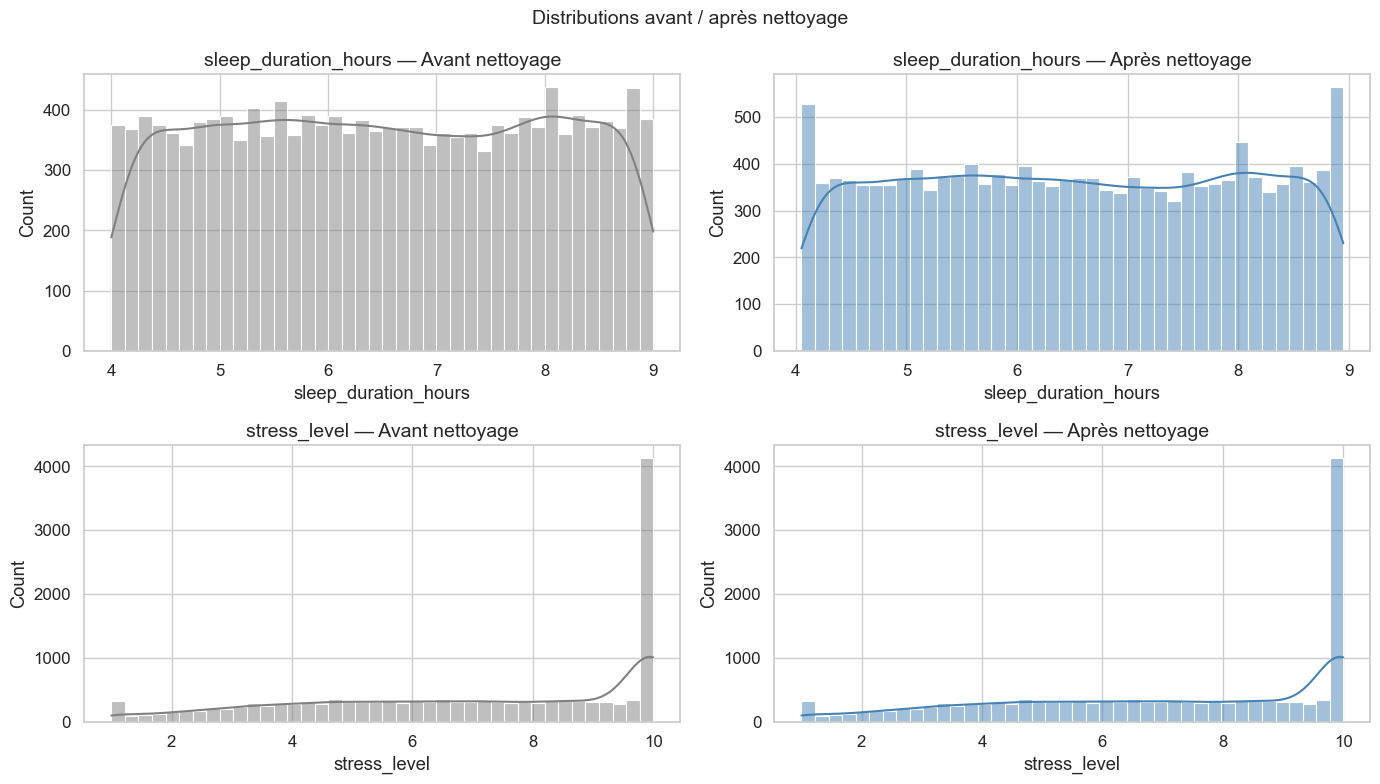

In [33]:
# Comparaison avant / après nettoyage pour les variables cibles
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(['sleep_duration_hours', 'stress_level']):
    sns.histplot(df_raw[col],   kde=True, ax=axes[i][0], color='gray',      label='Avant', bins=40)
    sns.histplot(df_clean[col], kde=True, ax=axes[i][1], color='steelblue', label='Après', bins=40)
    axes[i][0].set_title(f'{col} — Avant nettoyage')
    axes[i][1].set_title(f'{col} — Après nettoyage')
    for ax in axes[i]:
        ax.set_xlabel(col)

plt.suptitle('Distributions avant / après nettoyage', fontsize=14)
plt.tight_layout()
plt.show()

In [45]:
# Export du dataset nettoyé
output_path = 'dataset_clean.csv'
df_clean.to_csv(output_path, index=False)
print(f' Dataset nettoyé exporté : {output_path}')
print(f'   Dimensions : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes')
print(f'   Colonnes   : {list(df_clean.columns)}')

 Dataset nettoyé exporté : dataset_clean.csv
   Dimensions : 15,000 lignes × 15 colonnes
   Colonnes   : ['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'stress_level', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score', 'screen_time_bin', 'age_group']


---
## Conclusions de l'analyse exploratoire

### Ce qu'on a appris sur les données
| Aspect | Résultat |
|--------|----------|
| Qualité générale | Dataset de bonne qualité (pas/peu de valeurs manquantes, pas de doublons) |
| Outliers | Valeurs extrêmes écrêtées aux P1-P99 sur 5 variables continues |
| Normalité | Les variables cibles ne suivent pas strictement une loi normale → préférer des méthodes robustes |

### Relations clés identifiées
- **Temps d'écran ↑ → Durée du sommeil ↓** : corrélation négative confirmée
- **Temps d'écran ↑ → Niveau de stress ↑** : corrélation positive confirmée
- **Fatigue mentale** est fortement corrélée avec le stress (variables très liées)
- **Activité physique** a un effet protecteur sur le sommeil et le stress
- **Utilisation du téléphone avant le sommeil** impacte la qualité du sommeil

### Prochaines étapes
1. **Feature engineering** : création de nouvelles variables (ratios, interactions)
2. **Modélisation** : régression pour prédire la durée du sommeil et le niveau de stress
3. **Évaluation** : RMSE, R², validation croisée